In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install timm  # for pretrained CNN backbones

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = '/content/drive/MyDrive/STATUN3106 - Applied Machine Learning/Final Project/ML Final Project/'

                  image_path
0  lamem_subset/00000194.jpg
1  lamem_subset/00000198.jpg
2  lamem_subset/00000322.jpg
3  lamem_subset/00000599.jpg
4  lamem_subset/00000606.jpg
Dataset size: 500


KeyError: 'memorability'

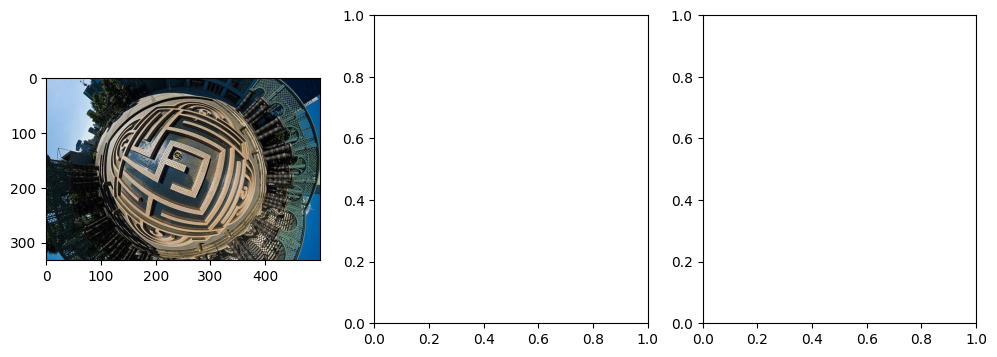

In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# LaMem comes with a CSV of image filenames + memorability scores
df = pd.read_csv(f'{base_path}Prototype/lamem_prototype_images/image_list.csv')
print(df.head())
print(f"Dataset size: {len(df)}")

# Sanity check: show a few images with their scores
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, ax in enumerate(axes):
    img = Image.open(f"{base_path}Prototype/lamem_prototype_images/{df.iloc[i]['image_path']}")
    ax.imshow(img)
    ax.set_title(f"Score: {df.iloc[i]['memorability']:.2f}")
    ax.axis('off')
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

class LaMemDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(f"{self.img_dir}/{self.df.iloc[idx]['image']}").convert('RGB')
        score = torch.tensor(self.df.iloc[idx]['memorability'], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, score

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_loader = DataLoader(LaMemDataset(train_df, img_dir, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(LaMemDataset(val_df, img_dir, transform), batch_size=32)

print(f"Train: {len(train_df)}, Val: {len(val_df)}")

In [ ]:
import torch.nn as nn
import timm

class MemorabilityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=True, num_classes=0)
        self.regressor = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
            nn.Sigmoid()  # memorability scores are between 0 and 1
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.regressor(features).squeeze()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MemorabilityModel().to(device)
print(f"Running on: {device}")

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for imgs, scores in loader:
        imgs, scores = imgs.to(device), scores.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for imgs, scores in loader:
            imgs, scores = imgs.to(device), scores.to(device)
            preds = model(imgs)
            total_loss += criterion(preds, scores).item()
    return total_loss / len(loader)

# For the prototype, even 2-3 epochs is enough to show it works
for epoch in range(3):
    train_loss = train_epoch(model, train_loader)
    val_loss = val_epoch(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

In [ ]:
torch.save(model.state_dict(), f'{base_path}Prototype/initial_pipeline/checkpoints/model_epoch3.pth')
print("Saved.")